# Identitas Diri
Nama : Muhammad Fattahul Alim

NIM : 244107020018

Kelas : TI - 3G

Absen : 15


In [1]:
# import library & setting
import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, Normalizer
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    pairwise_distances
)

from google.colab import drive
drive.mount('/content/drive')

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

RANDOM_STATE = 42
N_SAMPLE = 10000   # jumlah data yang sama untuk semua notebook (K-Means dan DBSCAN)
np.random.seed(RANDOM_STATE)

OUTPUT_DIR = "/content/drive/MyDrive/ml-sem5/kuis1/outputKmeans_5050"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("[INFO] Library berhasil diinstall.")
print(f"[INFO] Folder output: '{OUTPUT_DIR}' | Random state: {RANDOM_STATE} | N_SAMPLE: {N_SAMPLE}")

Mounted at /content/drive
[INFO] Library berhasil diinstall.
[INFO] Folder output: '/content/drive/MyDrive/ml-sem5/kuis1/outputKmeans_5050' | Random state: 42 | N_SAMPLE: 10000


In [2]:
# Load data
DATASET_PATH = '/content/drive/MyDrive/ml-sem5/kuis1/dataset/diabetes_binary_5050split_health_indicators_BRFSS2015.csv'
df_raw = pd.read_csv(DATASET_PATH)
print(f"Data awal: {df_raw.shape[0]} baris x {df_raw.shape[1]} kolom")
df_raw.head()

Data awal: 70692 baris x 22 kolom


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


In [3]:
# Cek data awal
print("Tipe data tiap kolom:")
print(df_raw.dtypes.value_counts())

print("\nTotal missing value per kolom (hanya yang > 0):")
missing = df_raw.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "Tidak ada missing value")

print(f"\nJumlah baris duplikat: {df_raw.duplicated().sum()}")

print("\nSebaran kelas Diabetes_binary (0 = tidak diabetes, 1 = diabetes):")
print(df_raw['Diabetes_binary'].value_counts().sort_index())

Tipe data tiap kolom:
float64    22
Name: count, dtype: int64

Total missing value per kolom (hanya yang > 0):
Tidak ada missing value

Jumlah baris duplikat: 1635

Sebaran kelas Diabetes_binary (0 = tidak diabetes, 1 = diabetes):
Diabetes_binary
0.0    35346
1.0    35346
Name: count, dtype: int64


In [4]:
# Preprocessing
LABEL_COL = 'Diabetes_binary'
DROP_COLS = ['Income', 'Education', 'AnyHealthcare', 'NoDocbcCost', 'CholCheck', 'HvyAlcoholConsump']

df = df_raw.drop(columns=DROP_COLS)
print(f"Setelah buang kolom        : {df.shape[1]} kolom (termasuk label)")

n_sebelum_dup = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Setelah hapus duplikat     : {len(df)} baris (terbuang {n_sebelum_dup - len(df)})")
print(f"Sebaran kelas              : {df[LABEL_COL].value_counts().sort_index().to_dict()}")

# Sampel seimbang: jumlah data per kelas sama, seed sama -> data identik di semua notebook
n_per_kelas = N_SAMPLE // 2
assert df[LABEL_COL].value_counts().min() >= n_per_kelas, "Salah satu kelas kurang dari jumlah sampel per kelas"
df_sample_all = (df.groupby(LABEL_COL).sample(n=n_per_kelas, random_state=RANDOM_STATE)
                   .sample(frac=1, random_state=RANDOM_STATE)
                   .reset_index(drop=True))

y_sample = df_sample_all[LABEL_COL].copy()   # label hanya untuk pembanding, tidak dipakai klastering
df_features = df_sample_all.drop(columns=[LABEL_COL]).astype(float)
print(f"Data klastering            : {df_features.shape[0]} baris x {df_features.shape[1]} fitur")
print(f"Sebaran label sampel       : {y_sample.value_counts().sort_index().to_dict()}")
print(f"Daftar fitur               : {list(df_features.columns)}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_features.values)
print(f"Cek mean 0 dan std 1       : {X_scaled.mean():.4f} / {X_scaled.std():.4f}")
X_norm = Normalizer(norm='l2').fit_transform(X_scaled)   # proyeksi ke unit hypersphere ||x|| = 1
print(f"Cek norma L2 tiga baris pertama (harus 1): {np.linalg.norm(X_norm[:3], axis=1)}")
df_features.head()

Setelah buang kolom        : 16 kolom (termasuk label)
Setelah hapus duplikat     : 63197 baris (terbuang 7495)
Sebaran kelas              : {0.0: 29885, 1.0: 33312}
Data klastering            : 10000 baris x 15 fitur
Sebaran label sampel       : {0.0: 5000, 1.0: 5000}
Daftar fitur               : ['HighBP', 'HighChol', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age']
Cek mean 0 dan std 1       : -0.0000 / 1.0000
Cek norma L2 tiga baris pertama (harus 1): [1. 1. 1.]


,HighBP,HighChol,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age
0,1.0,1.0,26.0,1.0,0.0,1.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,1.0,11.0
1,1.0,0.0,30.0,1.0,0.0,0.0,1.0,1.0,1.0,2.0,0.0,0.0,0.0,1.0,11.0
2,1.0,0.0,35.0,1.0,0.0,0.0,0.0,1.0,1.0,4.0,5.0,20.0,1.0,0.0,11.0
3,1.0,1.0,26.0,1.0,0.0,0.0,0.0,0.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0
4,0.0,0.0,24.0,1.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,1.0,7.0


In [5]:
# Model Kmeans
class KMeansCosine:
    def __init__(self, n_clusters=3, max_iter=300, tol=1e-4, random_state=42):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.centroids = None
        self.labels_ = None
        self.inertia_ = 0.0   # total cosine distance
        self.n_iter_ = 0
        self.execution_time_ = 0.0

    def _compute_distance(self, X, centroids):
        return pairwise_distances(X, centroids, metric='cosine')

    def _init_centroids(self, X):
        rng = np.random.RandomState(self.random_state)
        n_samples, _ = X.shape
        first_idx = rng.randint(n_samples)
        centroids = [X[first_idx]]
        for _ in range(1, self.n_clusters):
            dists = self._compute_distance(X, np.array(centroids))
            sq_dists = np.min(dists, axis=1) ** 2
            sum_sq = np.sum(sq_dists)
            probs = np.ones(n_samples) / n_samples if sum_sq == 0 else sq_dists / sum_sq
            centroids.append(X[rng.choice(n_samples, p=probs)])
        centroids = np.array(centroids)
        norms = np.linalg.norm(centroids, axis=1, keepdims=True)
        norms[norms == 0] = 1e-10
        return centroids / norms   # centroid ditaruh di bola satuan

    def fit(self, X):
        start_time = time.perf_counter()
        norms = np.linalg.norm(X, axis=1, keepdims=True)
        norms[norms == 0] = 1e-10
        X_calc = X / norms
        self.centroids = self._init_centroids(X_calc)

        for it in range(self.max_iter):
            self.n_iter_ = it + 1
            dists = self._compute_distance(X_calc, self.centroids)
            labels = np.argmin(dists, axis=1)

            new_centroids = np.zeros_like(self.centroids)
            rng = np.random.RandomState(self.random_state)
            for k in range(self.n_clusters):
                cluster_pts = X_calc[labels == k]
                if len(cluster_pts) == 0:
                    new_centroids[k] = X_calc[rng.randint(len(X_calc))]
                else:
                    mean_vec = np.mean(cluster_pts, axis=0)
                    norm = np.linalg.norm(mean_vec)
                    new_centroids[k] = mean_vec / (norm if norm > 0 else 1.0)   # update: rata-rata dinormalisasi

            shift = np.linalg.norm(new_centroids - self.centroids)
            self.centroids = new_centroids
            self.labels_ = labels
            if shift < self.tol:
                break

        final_dists = self._compute_distance(X_calc, self.centroids)
        assigned = final_dists[np.arange(len(X_calc)), self.labels_]
        self.inertia_ = float(np.sum(assigned))   # total cosine distance
        self.execution_time_ = float(time.perf_counter() - start_time)
        return self

print("[INFO] Kelas KMeansCosine berhasil diinisialisasi.")

[INFO] Kelas KMeansCosine berhasil diinisialisasi.


  k = 1  | Cosine Inertia = 9,302.55 | iterasi = 2
  k = 2  | Cosine Inertia = 6,340.31 | iterasi = 15
  k = 3  | Cosine Inertia = 5,625.19 | iterasi = 32
  k = 4  | Cosine Inertia = 5,128.19 | iterasi = 35
  k = 5  | Cosine Inertia = 4,842.29 | iterasi = 38
  k = 6  | Cosine Inertia = 4,570.74 | iterasi = 65
  k = 7  | Cosine Inertia = 4,295.66 | iterasi = 63
  k = 8  | Cosine Inertia = 4,232.44 | iterasi = 61
  k = 9  | Cosine Inertia = 4,005.55 | iterasi = 46
  k = 10 | Cosine Inertia = 3,809.83 | iterasi = 37
[ELBOW] Elbow metrik ini: k = 3 | k dipakai (acuan Euclidean): k = 4
[SIMPAN] Grafik Elbow disimpan ke: '/content/drive/MyDrive/ml-sem5/kuis1/outputKmeans_5050/elbow_cosine.png'


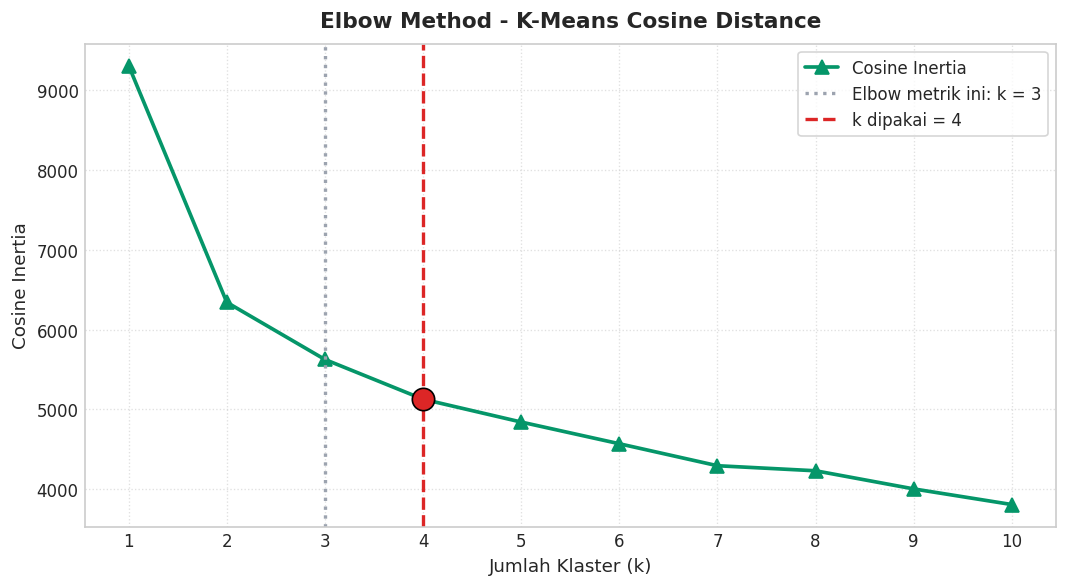

In [6]:
# Elbow Method Cosine
k_range = list(range(1, 11))
obj_list = []

for k in k_range:
    km = KMeansCosine(n_clusters=k, max_iter=200, random_state=RANDOM_STATE).fit(X_norm)
    obj_list.append(km.inertia_)
    print(f"  k = {k:<2} | Cosine Inertia = {km.inertia_:,.2f} | iterasi = {km.n_iter_}")

def find_elbow_point(k_vals, vals):
    # kedua sumbu dinormalisasi 0-1 agar deteksi siku sebanding antar metrik
    x = (np.array(k_vals, dtype=float) - k_vals[0]) / (k_vals[-1] - k_vals[0])
    y = (np.array(vals, dtype=float) - min(vals)) / (max(vals) - min(vals))
    p1 = np.array([x[0], y[0]])
    line_unit = np.array([x[-1], y[-1]]) - p1
    line_unit = line_unit / np.linalg.norm(line_unit)
    pts = np.column_stack([x, y]) - p1
    proj = np.outer(pts @ line_unit, line_unit)
    return k_vals[int(np.argmax(np.linalg.norm(pts - proj, axis=1)))]

elbow_k = find_elbow_point(k_range, obj_list)
# k disamakan dengan hasil elbow Euclidean (jalankan notebook Euclidean terlebih dahulu)
ref_path = os.path.join(OUTPUT_DIR, "evaluasi_kmeans_euclidean.xlsx")
if not os.path.exists(ref_path):
    raise FileNotFoundError("Jalankan notebook K-Means Euclidean lebih dulu: k acuan dibaca dari hasilnya.")
K_FINAL = int(pd.read_excel(ref_path, sheet_name='Ringkasan_Evaluasi')['Optimal k'].iloc[0])
print(f"[ELBOW] Elbow metrik ini: k = {elbow_k} | k dipakai (acuan Euclidean): k = {K_FINAL}")

plt.figure(figsize=(9, 5))
plt.plot(k_range, obj_list, marker='^', markersize=8, linewidth=2.2, color='#059669', label='Cosine Inertia')
plt.axvline(x=elbow_k, color='#9CA3AF', linestyle=':', linewidth=2, label=f'Elbow metrik ini: k = {elbow_k}')
plt.axvline(x=K_FINAL, color='#DC2626', linestyle='--', linewidth=2, label=f'k dipakai = {K_FINAL}')
plt.scatter([K_FINAL], [obj_list[K_FINAL - 1]], color='#DC2626', s=180, zorder=5, edgecolor='black')
plt.title('Elbow Method - K-Means Cosine Distance', fontsize=13, fontweight='bold', pad=10)
plt.xlabel('Jumlah Klaster (k)', fontsize=11)
plt.ylabel('Cosine Inertia', fontsize=11)
plt.xticks(k_range)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(frameon=True, facecolor='white')
plt.tight_layout()

elbow_path = os.path.join(OUTPUT_DIR, "elbow_cosine.png")
plt.savefig(elbow_path, dpi=300)
print(f"[SIMPAN] Grafik Elbow disimpan ke: '{elbow_path}'")
plt.show()

# Nilai kurva elbow disimpan untuk grafik gabungan di notebook perbandingan
pd.DataFrame({'k': k_range, 'objective': obj_list}).to_csv(os.path.join(OUTPUT_DIR, "elbow_values_cosine.csv"), index=False)

In [7]:
# Klastering Final, evaluasi dan implementasi hasil
model_kmeans = KMeansCosine(n_clusters=K_FINAL, max_iter=300, tol=1e-4, random_state=RANDOM_STATE).fit(X_norm)
labels = model_kmeans.labels_

sil_score = float(silhouette_score(X_norm, labels, metric='cosine'))
db_score = float(davies_bouldin_score(X_norm, labels))
ch_score = float(calinski_harabasz_score(X_norm, labels))

eval_df = pd.DataFrame([{
    'Distance Metric': 'Cosine Distance',
    'Optimal k': K_FINAL,
    'k Elbow (metrik ini)': elbow_k,
    'Jumlah Data': X_norm.shape[0],
    'Jumlah Fitur': X_norm.shape[1],
    'Silhouette Score (↑)': round(sil_score, 4),
    'Davies–Bouldin Index (↓)': round(db_score, 4),
    'Calinski–Harabasz Index (↑)': round(ch_score, 2),
    'Execution Time (s) (↓)': round(model_kmeans.execution_time_, 5),
    'Iterations (↓)': model_kmeans.n_iter_,
    'Objective Value (Cosine Inertia) (↓)': round(model_kmeans.inertia_, 2)
}])

print("\n" + "=" * 80)
print("TABEL EVALUASI K-MEANS COSINE")
print("=" * 80)
print(eval_df.T.to_string(header=False))
print("=" * 80)

df_clustered = df_features.copy()
df_clustered['Diabetes_binary'] = y_sample.values
df_clustered['Cluster_Cosine'] = labels

profil = df_clustered.groupby('Cluster_Cosine').mean().round(3)
profil.insert(0, 'Jumlah Data', df_clustered['Cluster_Cosine'].value_counts().sort_index())
profil['% Diabetes'] = (df_clustered.groupby('Cluster_Cosine')['Diabetes_binary'].apply(lambda s: (s == 1).mean() * 100)).round(2)

excel_path = os.path.join(OUTPUT_DIR, "evaluasi_kmeans_cosine.xlsx")
with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    eval_df.to_excel(writer, sheet_name='Ringkasan_Evaluasi', index=False)
    profil.to_excel(writer, sheet_name='Profil_Klaster')
print(f"[SIMPAN] Evaluasi & profil klaster disimpan ke: '{excel_path}'")

csv_path = os.path.join(OUTPUT_DIR, "data_terklaster_kmeans_cosine.csv")
df_clustered.to_csv(csv_path, index=False)
print(f"[SIMPAN] Data terklaster disimpan ke: '{csv_path}'")


TABEL EVALUASI K-MEANS COSINE
Distance Metric                       Cosine Distance
Optimal k                                           4
k Elbow (metrik ini)                                3
Jumlah Data                                     10000
Jumlah Fitur                                       15
Silhouette Score (↑)                           0.1921
Davies–Bouldin Index (↓)                       2.5023
Calinski–Harabasz Index (↑)                   1022.91
Execution Time (s) (↓)                        0.29504
Iterations (↓)                                     35
Objective Value (Cosine Inertia) (↓)          5128.19
[SIMPAN] Evaluasi & profil klaster disimpan ke: '/content/drive/MyDrive/ml-sem5/kuis1/outputKmeans_5050/evaluasi_kmeans_cosine.xlsx'
[SIMPAN] Data terklaster disimpan ke: '/content/drive/MyDrive/ml-sem5/kuis1/outputKmeans_5050/data_terklaster_kmeans_cosine.csv'


In [8]:
# Profil Tiap Klaster
profil

,Jumlah Data,HighBP,HighChol,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Diabetes_binary,% Diabetes
Cluster_Cosine,,,,,,,,,,,,,,,,,,
0,2008,0.717,0.608,30.635,0.509,0.027,0.117,0.671,0.004,0.600,2.713,1.786,1.836,0.057,0.628,8.899,0.531,53.14
1,3086,0.025,0.267,27.337,0.380,0.009,0.027,0.832,0.719,0.866,2.210,3.015,1.972,0.048,0.383,6.839,0.211,21.13
2,2850,0.780,0.710,32.827,0.620,0.166,0.321,0.420,0.562,0.718,3.955,9.126,17.527,0.819,0.378,9.415,0.731,73.05
3,2056,0.962,0.618,29.971,0.497,0.054,0.158,0.794,1.000,0.861,2.675,1.444,2.049,0.076,0.505,9.761,0.583,58.32


[SIMPAN] Grafik pemetaan klaster disimpan ke: '/content/drive/MyDrive/ml-sem5/kuis1/outputKmeans_5050/cluster_cosine.png'


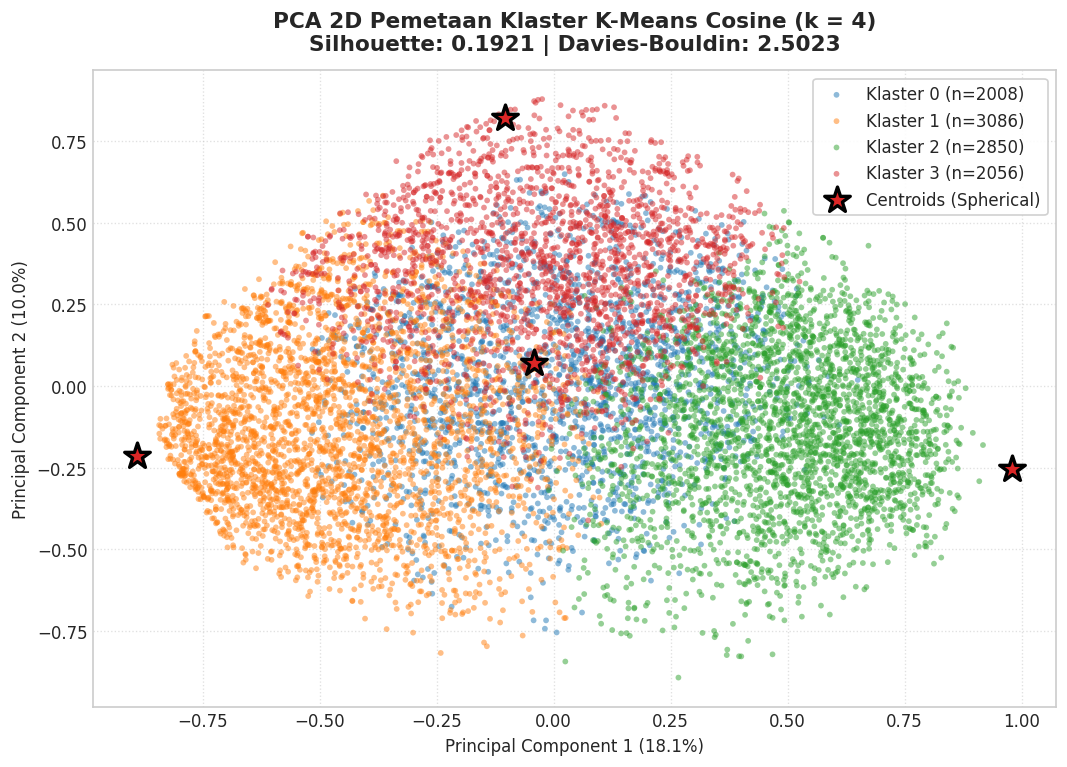

In [9]:
# Visualisasi
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_norm)
centroids_pca = pca.transform(model_kmeans.centroids)

plt.figure(figsize=(9, 6.5))
palette = sns.color_palette("tab10", K_FINAL)

for k in range(K_FINAL):
    mask = (labels == k)
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], color=palette[k], label=f'Klaster {k} (n={np.sum(mask)})',
                alpha=0.5, s=12, edgecolors='none')

plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], marker='*', s=260, c='#DC2626',
            edgecolor='black', linewidth=2, label='Centroids (Spherical)', zorder=10)

plt.title(f'PCA 2D Pemetaan Klaster K-Means Cosine (k = {K_FINAL})\n'
          f'Silhouette: {sil_score:.4f} | Davies-Bouldin: {db_score:.4f}',
          fontsize=13, fontweight='bold', pad=12)
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(frameon=True, facecolor='white', framealpha=0.9, loc='best')
plt.tight_layout()

cluster_path = os.path.join(OUTPUT_DIR, "cluster_cosine.png")
plt.savefig(cluster_path, dpi=300)
print(f"[SIMPAN] Grafik pemetaan klaster disimpan ke: '{cluster_path}'")
plt.show()


In [10]:
# Fitur paling berpengaruh
loadings = pd.DataFrame(pca.components_.T, index=df_features.columns, columns=['PC1', 'PC2'])
print("Fitur paling berpengaruh di PC1:")
print(loadings['PC1'].abs().sort_values(ascending=False).head(6).round(3))
print("\nFitur paling berpengaruh di PC2:")
print(loadings['PC2'].abs().sort_values(ascending=False).head(6).round(3))

Fitur paling berpengaruh di PC1:
GenHlth         0.424
DiffWalk        0.389
HighBP          0.380
PhysHlth        0.325
HighChol        0.301
PhysActivity    0.276
Name: PC1, dtype: float64

Fitur paling berpengaruh di PC2:
Age             0.492
HighBP          0.386
HighChol        0.354
Fruits          0.311
MentHlth        0.297
PhysActivity    0.258
Name: PC2, dtype: float64


In [11]:
#tabel sensitivitas k (k-1, k, k+1 dan k elbow metrik ini)
SIL_SAMPLE = None   # data penuh (Kaggle): isi 10000 agar Silhouette tidak terlalu lama
SENS_STEP = 1       # k yang diuji: K_FINAL - 1, K_FINAL, K_FINAL + 1

k_uji = sorted({k for k in [K_FINAL - SENS_STEP, K_FINAL, K_FINAL + SENS_STEP, int(elbow_k)] if 2 <= k <= max(k_range)})
rows = []

for k in k_uji:
    m = KMeansCosine(n_clusters=k, max_iter=300, tol=1e-4, random_state=RANDOM_STATE).fit(X_norm)
    lab = m.labels_
    ukuran = np.bincount(lab, minlength=k) / len(lab) * 100
    catatan = []
    if k == K_FINAL:
        catatan.append('k dipakai (acuan Euclidean)')
    if k == int(elbow_k):
        catatan.append('k elbow metrik ini')
    rows.append({
        'Distance Metric': 'Cosine',
        'k': k,
        'Keterangan': ' + '.join(catatan),
        'Silhouette (↑)': round(silhouette_score(X_norm, lab, metric='cosine', sample_size=SIL_SAMPLE, random_state=RANDOM_STATE), 4),
        'Davies–Bouldin (↓)': round(davies_bouldin_score(X_norm, lab), 4),
        'Calinski–Harabasz (↑)': round(calinski_harabasz_score(X_norm, lab), 2),
        'Klaster Terkecil (%)': round(ukuran.min(), 2),
        'Klaster Terbesar (%)': round(ukuran.max(), 2),
        'Iterasi (↓)': m.n_iter_
    })
    print(f"  k = {k} selesai")

sens_df = pd.DataFrame(rows)
print("\n" + "=" * 110)
print("TABEL SENSITIVITAS K - K-MEANS COSINE")
print("=" * 110)
print(sens_df.to_string(index=False))

sens_path = os.path.join(OUTPUT_DIR, "sensitivitas_k_cosine.csv")
sens_df.to_csv(sens_path, index=False)
print(f"[SIMPAN] Tabel sensitivitas disimpan ke: '{sens_path}'")

  k = 3 selesai
  k = 4 selesai
  k = 5 selesai

TABEL SENSITIVITAS K - K-MEANS COSINE
Distance Metric  k                  Keterangan  Silhouette (↑)  Davies–Bouldin (↓)  Calinski–Harabasz (↑)  Klaster Terkecil (%)  Klaster Terbesar (%)  Iterasi (↓)
         Cosine  3          k elbow metrik ini          0.1928              2.6367                1153.86                 27.34                 38.28           32
         Cosine  4 k dipakai (acuan Euclidean)          0.1921              2.5023                1022.91                 20.08                 30.86           35
         Cosine  5                                      0.1816              2.6356                 897.01                 15.74                 26.60           38
[SIMPAN] Tabel sensitivitas disimpan ke: '/content/drive/MyDrive/ml-sem5/kuis1/outputKmeans_5050/sensitivitas_k_cosine.csv'
